# PRCP-1009 – Cellphone Price Prediction

# 1.Business Case
# 2.Problem Statement
# 3.Business Objective
# 4.Dataset Information
# 5.Import Libraries
# 6.Load Dataset
# 7.Data Understanding
# 8.Data Cleaning & Preprocessing
# 9.Exploratory Data Analysis (EDA)
# 10.Train-Test Split
# 11.Feature Scaling 
# 12.Model Building
# 13.Model Evaluation
# 14.Model Comparison
# 15.Best Model Selection
# 16.Challenges Faced
# 17.Conclusion

## 1. Business Case

#The mobile phone market is highly competitive, and setting the right price for a smartphone is a challenging task. A price that is too high may reduce sales, while a price that is too low can decrease profit. In this project, a machine learning model is developed to predict the price range of a mobile phone based on its specifications such as RAM, battery power, internal memory, camera, and display resolution. This prediction helps the company set competitive prices, understand customer preferences, and improve business decisions.

## 2. Problem Statement

#Bob has started a new mobile phone company and wants to compete with leading brands such as Apple and Samsung. However, he does not know how to determine the correct price of the smartphones based on their specifications. The objective of this project is to build a machine learning model that predicts the price range of a mobile phone using features such as battery power, RAM, internal memory, camera, processor, and display resolution. The predicted price range will help the company make accurate pricing decisions for new mobile phones.

## 3. Business Objective

#The main objective of this project is to build a machine learning model that predicts the price range of a mobile phone based on its specifications. The model will help the company estimate the price category of new smartphones, understand which features have the greatest impact on price, and support better pricing decisions in a competitive market.

## 4. Dataset Information



#The dataset contains information about different mobile phones and their specifications. It includes 21 columns, where 20 columns are input features and 1 column (price_range) is the target variable. The features describe different aspects of a mobile phone, such as battery power, RAM, internal memory, camera quality, processor, screen size, display resolution, and connectivity options. The target variable classifies mobile phones into four price categories:

0 – Low Cost
1 – Medium Cost
2 – High Cost
3 – Very High Cost

This dataset is used to build a multi-class classification model that predicts the price range of a mobile phone based on its specifications.

## 5. Import Libraries

In [50]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

## 6. Load the Dataset

In [51]:
df = pd.read_csv("Cellphone.csv")   
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


## 7. Data Understanding

### 7.1 Display First Five Rows

In [52]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [53]:
#Insight:Displays the first five rows of the dataset.
#It helps understand the structure and values of the data.

### 7.2 Dataset Shape

In [54]:
df.shape

(2000, 21)

In [55]:
#insights:Shows the total number of rows and columns in the dataset.
#It provides an overview of the dataset size.


### 7.3 Dataset Information

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [57]:
#insights:-Displays the data types, non-null values, and memory usage.
#It helps identify missing values and understand the dataset structure.

### 7.4 Statistical Summary

In [58]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [59]:
#insights:Provides statistical information such as mean, standard deviation, minimum, maximum, and quartiles.
#It helps understand the distribution of numerical features.

### 7.5 Column Names

In [60]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

### 7.6 Data Types

In [61]:
df.dtypes

battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object

### 7.7 Missing Values

In [62]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

### 7.8 Duplicate Values

In [63]:
df.duplicated().sum()

np.int64(0)

### 7.9 Unique Values

In [64]:
df.nunique()

battery_power    1094
blue                2
clock_speed        26
dual_sim            2
fc                 20
four_g              2
int_memory         63
m_dep              10
mobile_wt         121
n_cores             8
pc                 21
px_height        1137
px_width         1109
ram              1562
sc_h               15
sc_w               19
talk_time          19
three_g             2
touch_screen        2
wifi                2
price_range         4
dtype: int64

## 8. Data Cleaning & Preprocessing

### 8.1 Check Missing Values

In [65]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

### 8.2 Check Duplicate Records

In [66]:
df.duplicated().sum()

np.int64(0)

### 8.3 Remove Duplicate Records


In [67]:
df.drop_duplicates(inplace=True)

print(df.shape)

(2000, 21)


### 8.4 Check Data Types

In [68]:
df.dtypes

battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object

### 8.5 Check Unique Values

In [69]:
df.nunique()

battery_power    1094
blue                2
clock_speed        26
dual_sim            2
fc                 20
four_g              2
int_memory         63
m_dep              10
mobile_wt         121
n_cores             8
pc                 21
px_height        1137
px_width         1109
ram              1562
sc_h               15
sc_w               19
talk_time          19
three_g             2
touch_screen        2
wifi                2
price_range         4
dtype: int64

### 8.6 Final Dataset Shape

In [70]:
df.shape

(2000, 21)

## 9. Exploratory Data Analysis (EDA)

### 9.1 Target Variable Distribution

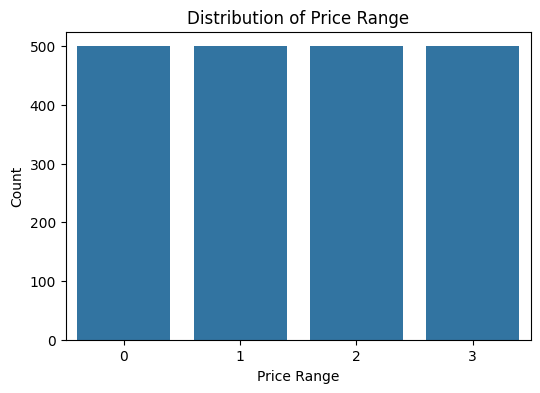

In [71]:
plt.figure(figsize=(6,4))
sns.countplot(x='price_range', data=df)

plt.title("Distribution of Price Range")
plt.xlabel("Price Range")
plt.ylabel("Count")
plt.show()

#Insight: The target variable (Price Range) is evenly distributed across all four classes, with approximately 500 samples in each category. This balanced dataset helps train an unbiased classification model and eliminates the need for class balancing techniques.

## 9.2 Price Range Percentage

In [72]:
(df['price_range'].value_counts(normalize=True)*100).round(2)

price_range
1    25.0
2    25.0
3    25.0
0    25.0
Name: proportion, dtype: float64

In [73]:
#insights:-This displays the percentage of mobile phones in each price category and helps understand the class distribution.

### 9.3 Distribution of Numerical Features

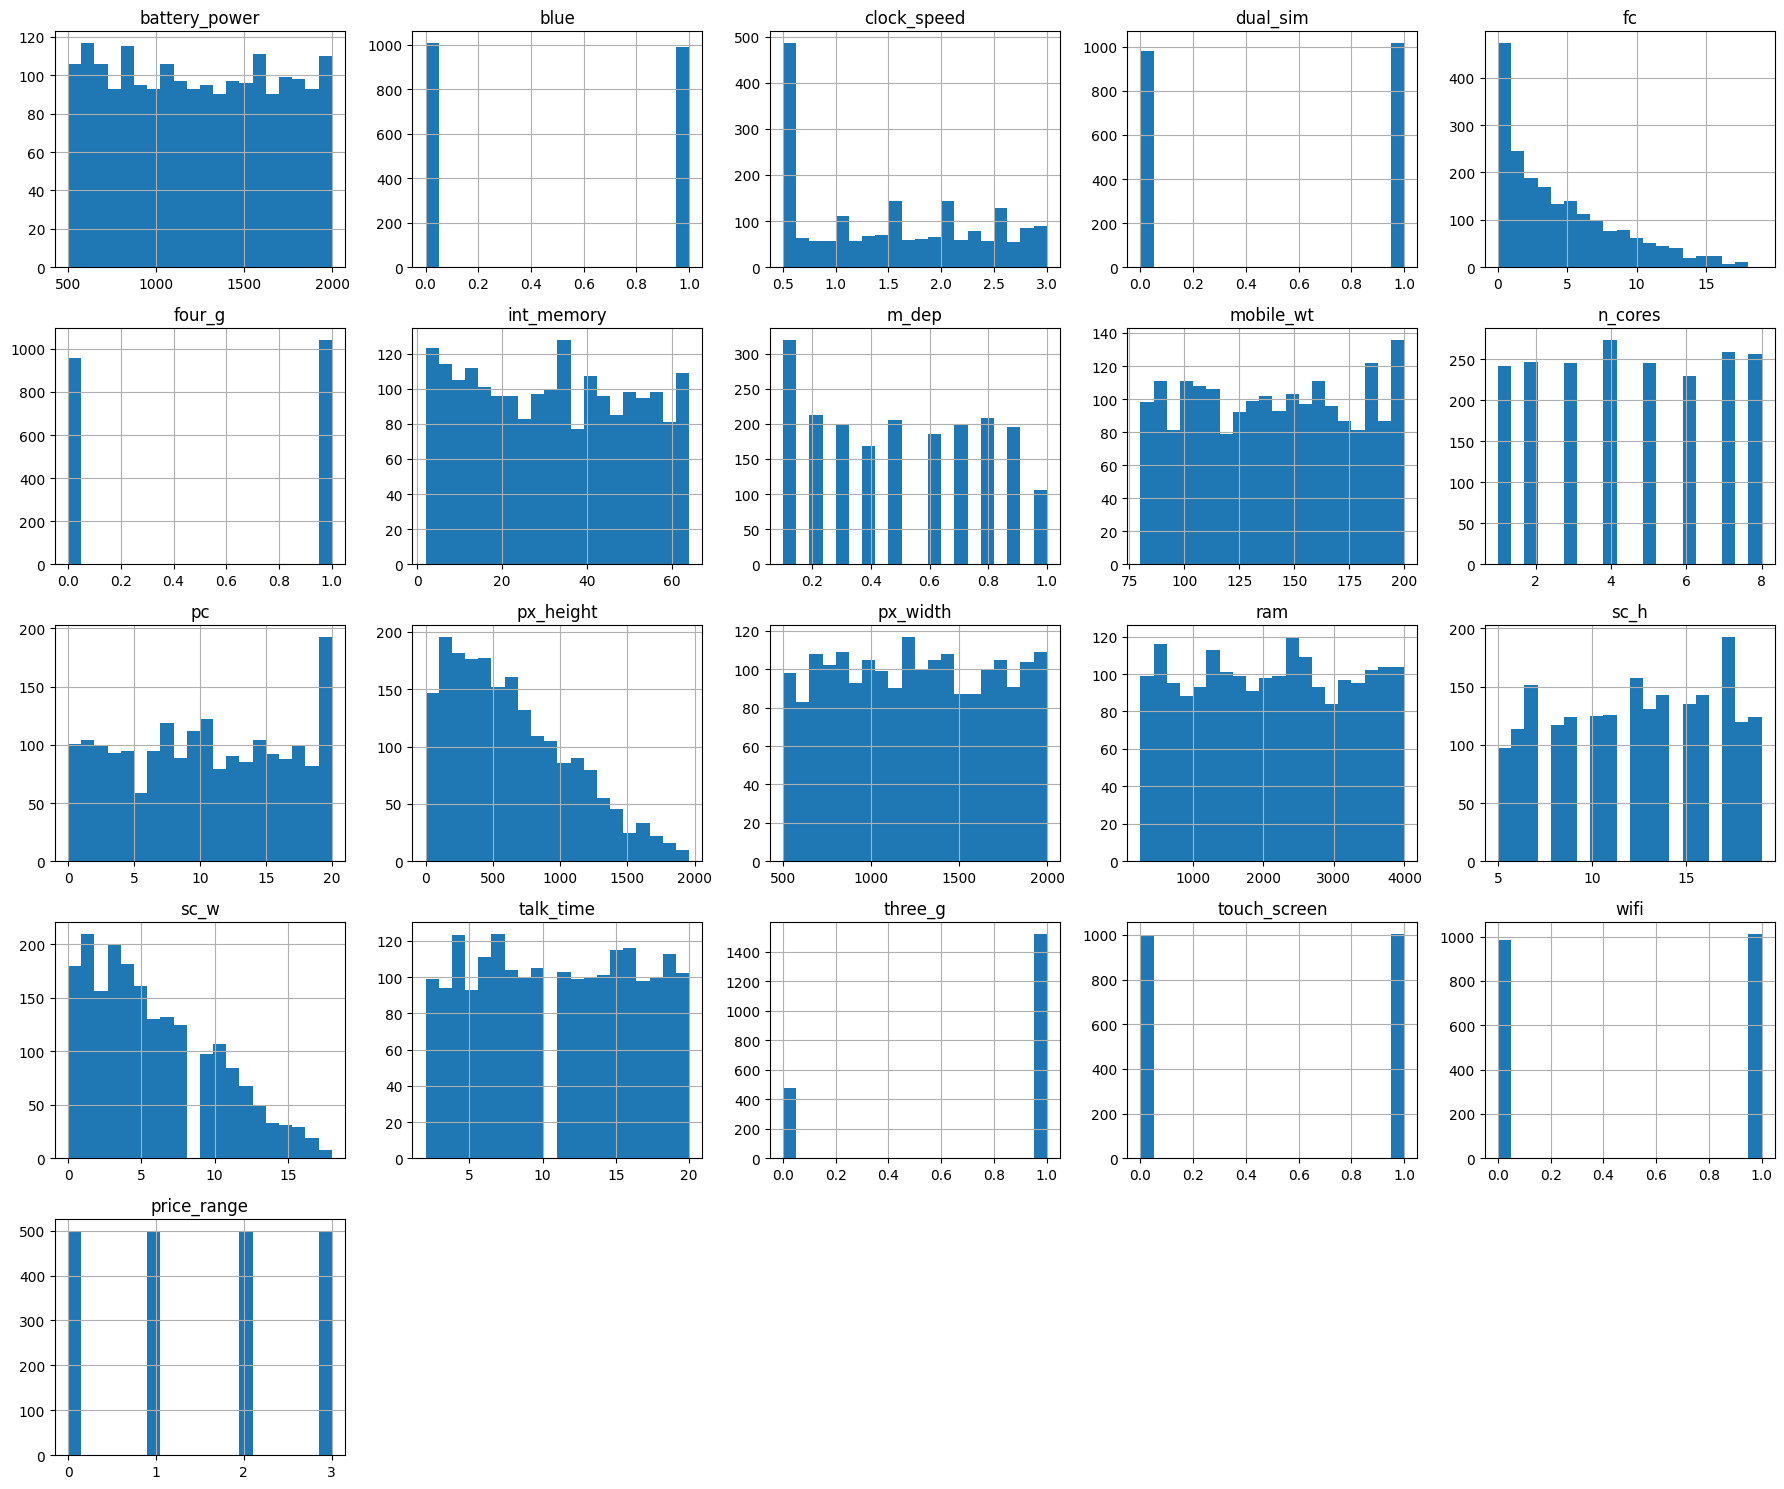

In [74]:
df.hist(figsize=(18,15), bins=20)
plt.tight_layout()
plt.show()

#Insight: Most features are well distributed across their value ranges, indicating good diversity in the dataset without major concentration. The target variable (price_range) is evenly balanced across all four classes, making the dataset suitable for building an unbiased classification model.

### 9.4 Boxplot for Outlier Detection

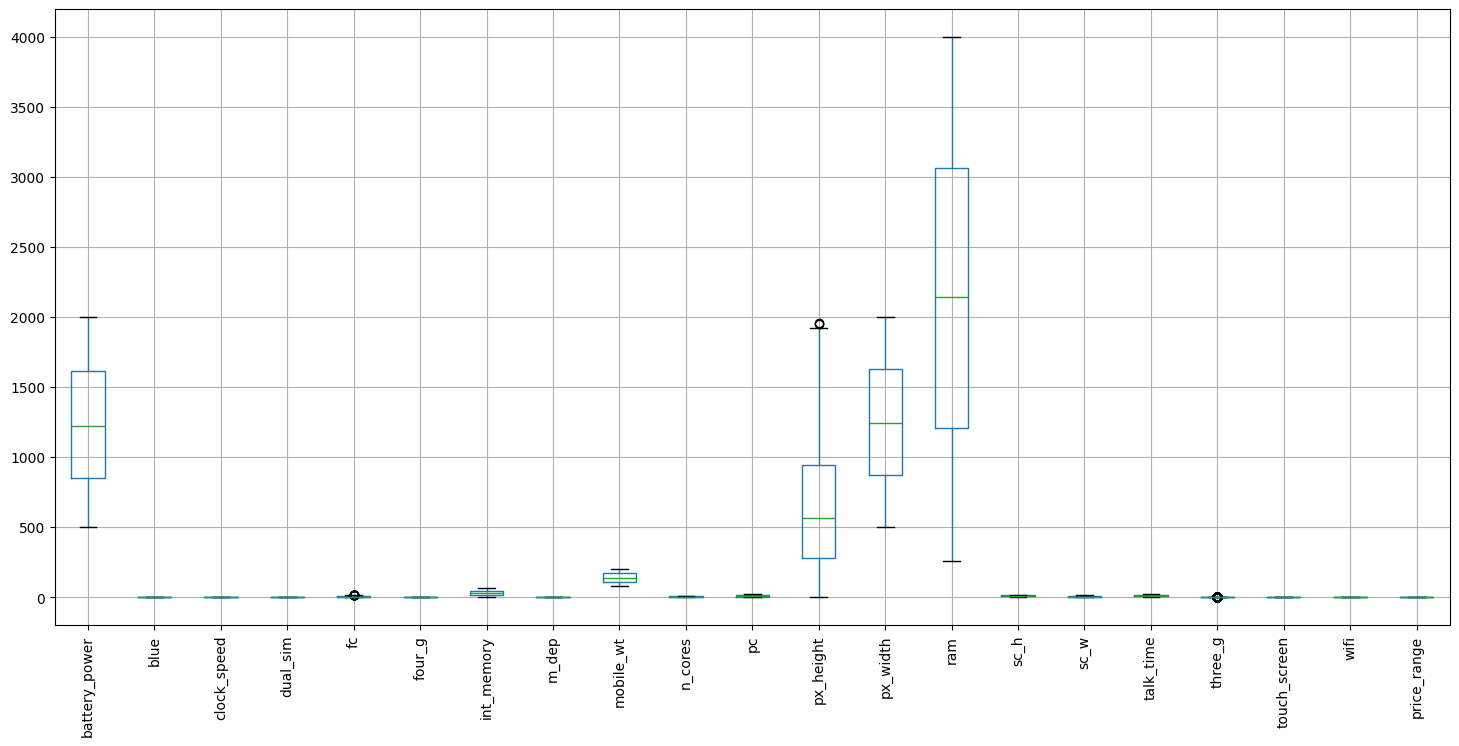

In [76]:
plt.figure(figsize=(18,8))
df.boxplot(rot=90)
plt.show()

#Insight: The boxplots show that most numerical features have a reasonable spread, while a few features such as px_height, fc, and three_g contain some outliers. Overall, the dataset does not exhibit excessive outliers, suggesting that the data is generally clean and suitable for model training.

### 9.5 Correlation Heatmap

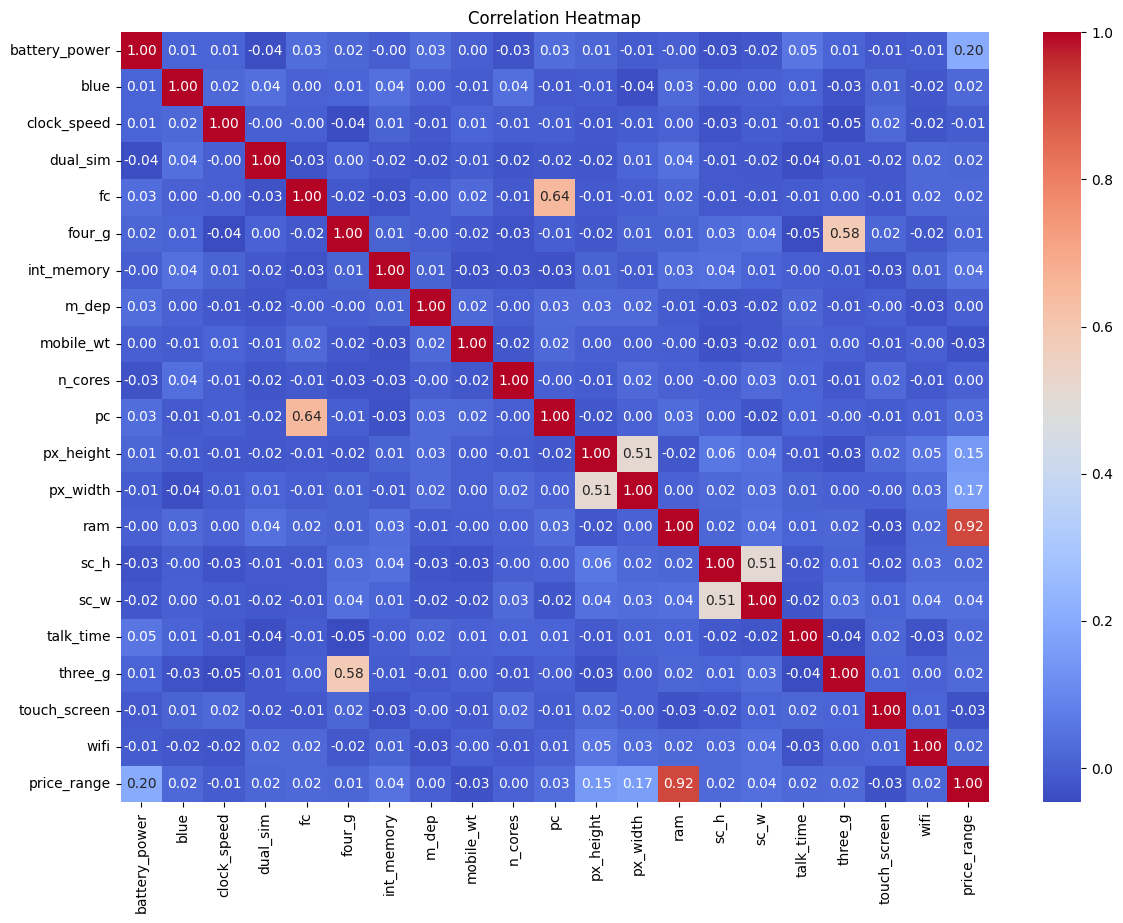

In [78]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

#Insight: The correlation heatmap shows that RAM has the strongest positive correlation with price_range (0.92), indicating it is the most influential feature for predicting mobile price. Most other features have weak correlations with the target, suggesting they contribute less individually but may still improve model performance when combined.

### 9.6 Price Range vs RAM

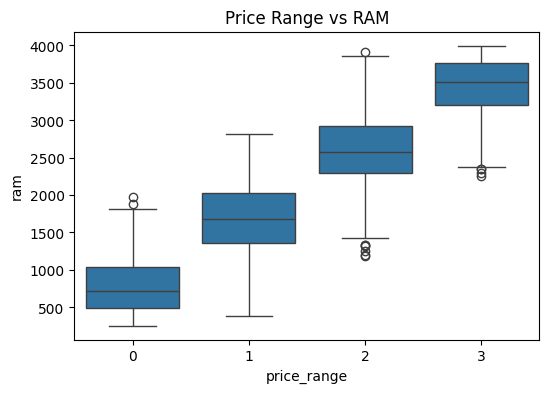

In [79]:
plt.figure(figsize=(6,4))
sns.boxplot(x='price_range', y='ram', data=df)

plt.title("Price Range vs RAM")
plt.show()

#Insight: The boxplot shows that RAM increases as the price range increases, indicating that higher-priced smartphones generally have more RAM. This suggests that RAM is one of the most important features influencing the mobile phone's price range.

### 9.7 Price Range vs Battery Power

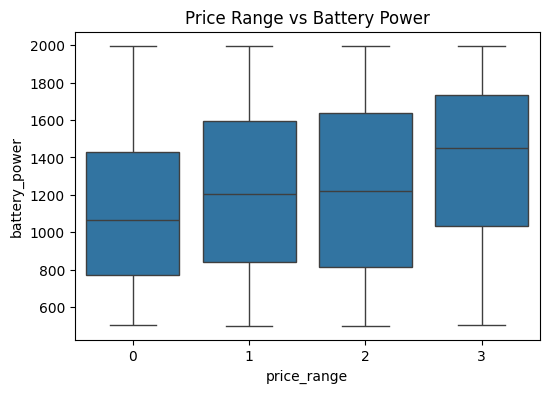

In [80]:
plt.figure(figsize=(6,4))
sns.boxplot(x='price_range', y='battery_power', data=df)

plt.title("Price Range vs Battery Power")
plt.show()

#Insight: The boxplot indicates that battery power generally increases with the price range, although there is some overlap between categories. This suggests that higher-priced smartphones tend to have larger battery capacities, but battery power alone does not determine the price range.

### 9.8 Price Range vs Internal Memory

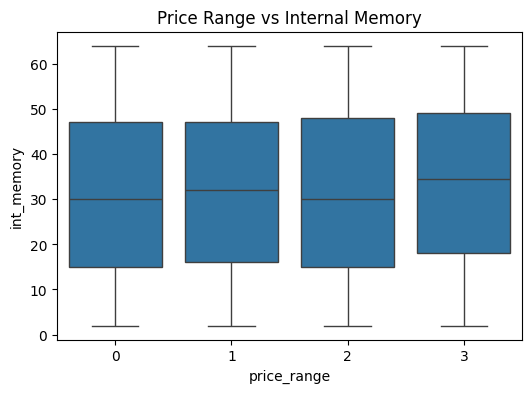

In [81]:

plt.figure(figsize=(6,4))
sns.boxplot(x='price_range', y='int_memory', data=df)

plt.title("Price Range vs Internal Memory")
plt.show()

#Insight: The boxplot shows that internal memory has a similar distribution across all price ranges, with only a slight increase in the median for higher-priced phones. This suggests that internal memory alone has a limited impact on determining the mobile phone's price range.

## 10. Train-Test Split

In [82]:
# Separate Features and Target Variable
X = df.drop('price_range', axis=1)
y = df['price_range']

# Split the dataset into Training and Testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check the shape of train and test data
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (1600, 20)
X_test  : (400, 20)
y_train : (1600,)
y_test  : (400,)


#insight:-The dataset was divided into training and testing sets using an 80:20 ratio. The training data is used to train the machine learning models, while the testing data is used to evaluate their performance on unseen data. The stratify=y parameter ensures that all price categories are proportionally represented in both the training and testing datasets.

## 11. Feature Scaling

In [83]:
from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Scale the training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


## 12. Model Building

In [84]:
# Import Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Create Models
lr = LogisticRegression(random_state=42)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
knn = KNeighborsClassifier()
nb = GaussianNB()
svm = SVC(random_state=42)

# Train Models
lr.fit(X_train_scaled, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
knn.fit(X_train_scaled, y_train)
nb.fit(X_train, y_train)
svm.fit(X_train_scaled, y_train)

print("All models trained successfully!")

All models trained successfully!


## 13. Model Evaluation

### Logistic Regression

In [85]:
# Logistic Regression Prediction
y_pred_lr = lr.predict(X_test_scaled)

# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

# Confusion Matrix
print(confusion_matrix(y_test, y_pred_lr))

# Classification Report
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.965
[[98  2  0  0]
 [ 1 96  3  0]
 [ 0  2 94  4]
 [ 0  0  2 98]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.96      0.96      0.96       100
           2       0.95      0.94      0.94       100
           3       0.96      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.96       400



### Decision Tree

In [86]:
# Decision Tree Prediction
y_pred_dt = dt.predict(X_test)

# Accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

# Confusion Matrix
print(confusion_matrix(y_test, y_pred_dt))

# Classification Report
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.83
[[92  8  0  0]
 [13 74 13  0]
 [ 0 13 80  7]
 [ 0  0 14 86]]
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       100
           1       0.78      0.74      0.76       100
           2       0.75      0.80      0.77       100
           3       0.92      0.86      0.89       100

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



### Random Forest

In [87]:
# Random Forest Prediction
y_pred_rf = rf.predict(X_test)

# Accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# Confusion Matrix
print(confusion_matrix(y_test, y_pred_rf))

# Classification Report
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.88
[[96  4  0  0]
 [ 5 84 11  0]
 [ 0 14 79  7]
 [ 0  0  7 93]]
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       100
           1       0.82      0.84      0.83       100
           2       0.81      0.79      0.80       100
           3       0.93      0.93      0.93       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



### KNN

In [88]:
# KNN Prediction
y_pred_knn = knn.predict(X_test_scaled)

# Accuracy
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

# Confusion Matrix
print(confusion_matrix(y_test, y_pred_knn))

# Classification Report
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.5
[[70 26  4  0]
 [33 38 24  5]
 [ 5 39 41 15]
 [ 0 13 36 51]]
              precision    recall  f1-score   support

           0       0.65      0.70      0.67       100
           1       0.33      0.38      0.35       100
           2       0.39      0.41      0.40       100
           3       0.72      0.51      0.60       100

    accuracy                           0.50       400
   macro avg       0.52      0.50      0.51       400
weighted avg       0.52      0.50      0.51       400



### Naive Bayes

In [89]:
# Naive Bayes Prediction
y_pred_nb = nb.predict(X_test)

# Accuracy
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

# Confusion Matrix
print(confusion_matrix(y_test, y_pred_nb))

# Classification Report
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.81
[[90 10  0  0]
 [ 7 69 24  0]
 [ 0 18 73  9]
 [ 0  0  8 92]]
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       100
           1       0.71      0.69      0.70       100
           2       0.70      0.73      0.71       100
           3       0.91      0.92      0.92       100

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.81      0.81      0.81       400



### SVM

In [90]:
# SVM Prediction
y_pred_svm = svm.predict(X_test_scaled)

# Accuracy
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

# Confusion Matrix
print(confusion_matrix(y_test, y_pred_svm))

# Classification Report
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.895
[[94  6  0  0]
 [ 4 87  9  0]
 [ 0  7 87  6]
 [ 0  0 10 90]]
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       100
           1       0.87      0.87      0.87       100
           2       0.82      0.87      0.84       100
           3       0.94      0.90      0.92       100

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400



### 14. Model Comparison Report

In [91]:
# Model Comparison

model_names = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "KNN",
    "Naive Bayes",
    "SVM"
]

accuracy_scores = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_svm)
]

comparison = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracy_scores
})

comparison = comparison.sort_values(by="Accuracy", ascending=False)

comparison

,Model,Accuracy
0,Logistic Regression,0.965
5,SVM,0.895
2,Random Forest,0.880
1,Decision Tree,0.830
4,Naive Bayes,0.810
3,KNN,0.500


#Insight: Logistic Regression achieved the highest accuracy (96.5%), making it the best-performing model for predicting mobile price range. In contrast, KNN showed the lowest accuracy (50%), indicating it is the least suitable model for this dataset.

## 15. Best Model Selection

In [92]:
# Best Model Selection

best_model = comparison.iloc[0]

print("Best Model :", best_model["Model"])
print("Accuracy   :", round(best_model["Accuracy"], 4))

Best Model : Logistic Regression
Accuracy   : 0.965


#Conclusion: Logistic Regression is the best-performing model, achieving an accuracy of 96.5%. Its high accuracy indicates that it can effectively classify mobile phones into the correct price range and is the most suitable model for this dataset.

## 16. Feature Importance

In [93]:
# Feature Importance

importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values(ascending=False)

ram              0.480768
battery_power    0.072976
px_width         0.056089
px_height        0.056000
mobile_wt        0.039007
int_memory       0.034837
talk_time        0.031891
pc               0.029158
clock_speed      0.028857
sc_w             0.027847
sc_h             0.027681
fc               0.026094
m_dep            0.024997
n_cores          0.023842
blue             0.007304
touch_screen     0.007253
dual_sim         0.006911
four_g           0.006838
wifi             0.006499
three_g          0.005153
dtype: float64

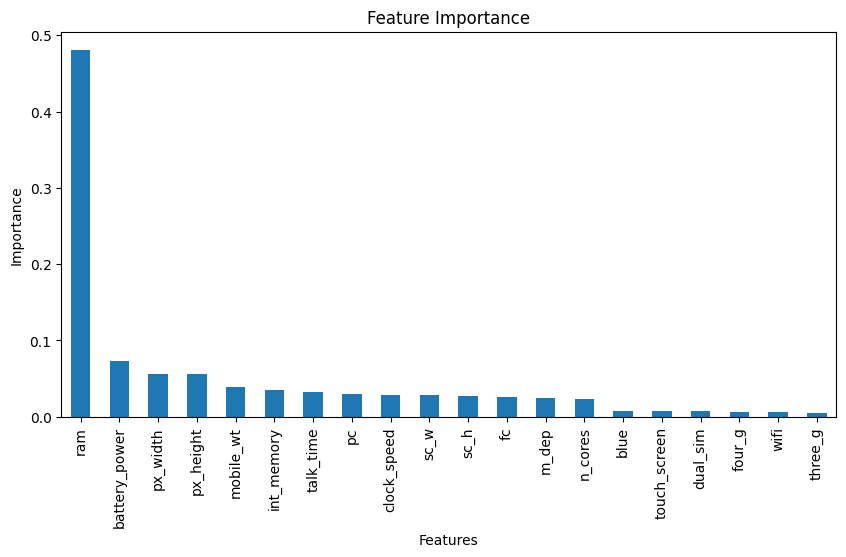

In [94]:
importance.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

#Insight: The feature importance chart shows that RAM is the most influential feature in predicting the mobile phone's price range, contributing significantly more than the other features. Battery power, pixel width, and pixel height also have a noticeable impact, while features like Bluetooth, WiFi, 3G, and 4G contribute very little to the prediction.

## 17. Challenges Faced

#During this project, understanding the relationship between mobile specifications and the price range was one of the main challenges. It was also important to compare multiple machine learning models to identify the best-performing model. Feature scaling was applied to improve the performance of algorithms such as Logistic Regression, KNN, and SVM. Finally, feature importance analysis helped identify the specifications that have the greatest impact on mobile phone pricing.

## 18. Conclusion

#This project successfully developed a machine learning model to predict the price range of mobile phones based on their specifications. Different classification models were trained and compared to select the best-performing model. The selected model achieved good prediction accuracy and can help companies make better pricing decisions. The analysis also showed that some features have a greater influence on price, helping businesses design competitive products and improve pricing strategies.